# What does it cost to measure a Student-t player?

Notebook 22 taught the solvers to throw a Student-t. It could not teach anything
to *estimate* one, so a real player still could not be handed a `ν` and a core
scale from their scoresheet: `darts/fitting.py` had a Gaussian M step, and
`darts/design.py` built the score function of a Gaussian **likelihood** -- not
merely of a Gaussian throw. Notebook 09's Fisher information, notebook 10's
"233 darts to prove a millimetre" and the criteria in notebook 17 were all
correctly computed for the wrong model.

This notebook fixes both and asks what moved. The roadmap posed the question
sharply enough to be answered rather than discussed:

> Which way they move is not obvious and has not been computed: heavy tails can
> carry more information about a scale than a Gaussian does, not less.

They move one way, in every band, and by more than a little.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.design import (best_single_target, candidate_targets, darts_to_detect,
                          design_information, information_at_points,
                          information_maps, kernel_derivatives, sigma_gradient,
                          sigma_standard_error)
from darts.fitting import (NU_GRID, ScoreLikelihood, fit_multi_target,
                           profile_nu, simulate_session)
from darts.players import ABILITY_BANDS
from darts.transitions import matched_scale
from darts.utils import mm_per_pixel, region_label

FIT_PX = 256          # the resolution the fitting notebooks use
DESIGN_PX = 512       # the resolution the design results were published at
NU = 2.25             # what notebook 21 fitted to real professionals
BOARD = generate_dartboard(FIT_PX)[0]
BOARD512 = generate_dartboard(DESIGN_PX)[0]
MM = mm_per_pixel(FIT_PX)
BANDS = list(ABILITY_BANDS)
DESIGN = [np.array([0.0, 103.0]), np.zeros(2), np.array([-100.0, 0.0])]
print('ready')

ready


## 1 · The whole change is one weight

A Student-t is a Gaussian whose width is redrawn for every dart:

$$Z \mid W \sim N(\mu,\ \Sigma / W), \qquad W \sim \text{Gamma}(\nu/2,\ \nu/2).$$

That reading is what makes it cheap to fit. The landing point was already latent
-- only the score is written down -- and the dart's own width is a *second*
latent that slots into the sum the first one already needed. The E step gains

$$u(z) \;=\; \mathbb{E}[W \mid Z = z] \;=\; \frac{\nu + 2}{\nu + q(z)},
\qquad q = (z-\mu)^\top \Sigma^{-1} (z-\mu)$$

applied pixel by pixel, and the M step is the *same* weighted Gaussian one.

That single factor is the whole behavioural difference, and it says something
plain. Under a Gaussian, a dart a long way from the aim point is powerful
evidence that the player is wide, because being wide is the only available
explanation. Under a t it is discounted, because a wide *dart* will do instead.

In [2]:
like = ScoreLikelihood(board=BOARD, nu=NU)
gauss_like = ScoreLikelihood(board=BOARD)
Sigma = 12.0 ** 2 * np.eye(2)
t20 = np.array([0.0, 103.0])

w = like.mixture_weight(t20, Sigma)
r = np.linalg.norm(like.coords - t20, axis=1)
print(f'the weight a dart gets, as a function of how far out it landed '
      f'(scale 12mm, nu={NU}):')
for d in (0, 12, 24, 48, 96):
    j = int(np.argmin(np.abs(r - d)))
    print(f'   {d:>3}mm from the aim point ({d / 12:.0f} scales out):  u = {w[j]:.4f}')
print(f'\na Gaussian gives every one of them u = '
      f'{gauss_like.mixture_weight(t20, Sigma)[0]:.4f}')

the weight a dart gets, as a function of how far out it landed (scale 12mm, nu=2.25):
     0mm from the aim point (0 scales out):  u = 1.8850
    12mm from the aim point (1 scales out):  u = 1.3057
    24mm from the aim point (2 scales out):  u = 0.6795
    48mm from the aim point (4 scales out):  u = 0.2328
    96mm from the aim point (8 scales out):  u = 0.0642

a Gaussian gives every one of them u = 1.0000


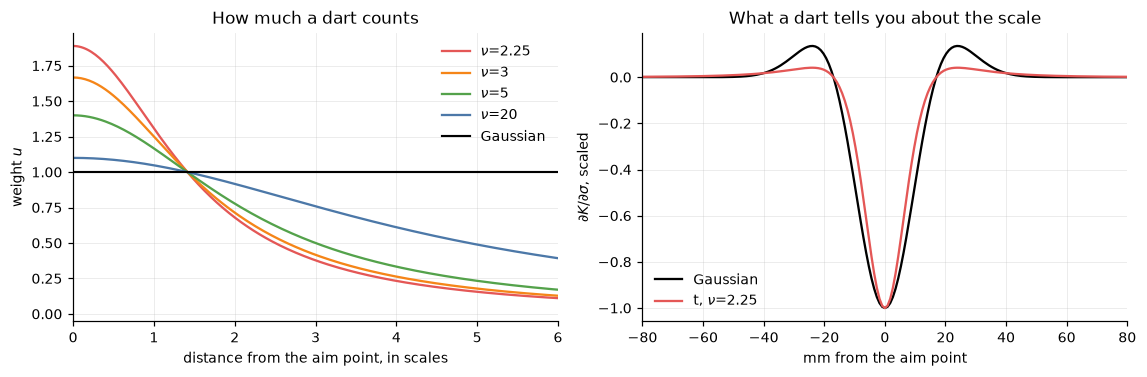

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
rr = np.linspace(0, 120, 400)
for nu, col in zip((2.25, 3.0, 5.0, 20.0), ('#e45756', '#f58518', '#54a24b', '#4c78a8')):
    ax[0].plot(rr / 12.0, (nu + 2) / (nu + (rr / 12.0) ** 2), color=col, lw=1.5,
               label=f'$\\nu$={nu:g}')
ax[0].axhline(1.0, color='k', lw=1.4, label='Gaussian')
ax[0].set(xlabel='distance from the aim point, in scales', ylabel='weight $u$',
          xlim=(0, 6), title='How much a dart counts')
ax[0].legend()

# the same weight, as the design side sees it: the score function
mm512 = mm_per_pixel(DESIGN_PX)
_, dKg = kernel_derivatives(DESIGN_PX, Sigma, mm512, params='isotropic')
_, dKt = kernel_derivatives(DESIGN_PX, Sigma, mm512, params='isotropic', nu=NU)
c = DESIGN_PX // 2
xs = (np.arange(DESIGN_PX) - c) * mm512
ax[1].plot(xs, dKg[2][c] / np.abs(dKg[2]).max(), 'k-', lw=1.5, label='Gaussian')
ax[1].plot(xs, dKt[2][c] / np.abs(dKt[2]).max(), color='#e45756', lw=1.5,
           label=f't, $\\nu$={NU:g}')
ax[1].set(xlabel='mm from the aim point', ylabel=r'$\partial K/\partial\sigma$, scaled',
          xlim=(-80, 80), title='What a dart tells you about the scale')
ax[1].legend()
fig.tight_layout()

A dart in the middle of the group counts for **1.89**; one four scales out counts
for **0.23**; one eight scales out counts for **0.06**. A Gaussian counts every
one of them as 1.

The right-hand panel is the same weight seen from the design side, and it is
where the consequence is easiest to read. $\partial K/\partial\sigma$ is what a
dart landing at a given place tells you about the player's width. Under a
Gaussian the curve keeps growing outward -- the further out a dart lands, the
louder it shouts "wide player", without limit, because that is the only story
available. Under a t it rises, turns over and comes back to nothing: a dart far
enough out has stopped being evidence about the player at all, because it is
better explained as one wide dart.

That is a change of shape, not of size, and it is why the design numbers in
section 6 have to be recomputed rather than scaled.

## 2 · The control, and then the recovery

Same discipline as notebook 22: the t nests the Gaussian, so at $\nu = \infty$
the new E step, the new M step and the new density have to give the old answer
back. Then the question worth asking -- can it recover a t it has never seen?

In [4]:
sessions_g = simulate_session(DESIGN, 200, [2.0, -3.0], 12.0 ** 2 * np.eye(2),
                              board=BOARD, seed=2)
a = fit_multi_target(sessions_g, board=BOARD, tol=1e-12, max_iter=2000)
b = fit_multi_target(sessions_g, board=BOARD, tol=1e-12, max_iter=2000, nu=np.inf)
print('nu = inf against the Gaussian EM:')
print(f'   scale   {a["sigma_mm"]:.9f}  vs  {b["sigma_mm"]:.9f}')
print(f'   bias    {np.round(a["b"], 9)}  vs  {np.round(b["b"], 9)}')
print(f'   log-lik {a["log_likelihood"]:.9f}  vs  {b["log_likelihood"]:.9f}')

nu = inf against the Gaussian EM:
   scale   12.396039760  vs  12.396039760
   bias    [ 2.5375231  -2.71980215]  vs  [ 2.5375231  -2.71980215]
   log-lik -939.931882372  vs  -939.931882372


In [5]:
SCALE, B_TRUE = 8.0, np.array([2.0, -3.0])
sessions_t = simulate_session(DESIGN, 250, B_TRUE, SCALE ** 2 * np.eye(2),
                              board=BOARD, seed=3, nu=NU)
rows = []
for nu in (None, NU):
    f = fit_multi_target(sessions_t, board=BOARD, tol=1e-11, max_iter=1500, nu=nu)
    rows.append(dict(fitted_as='gaussian' if nu is None else f't, nu={NU:g}',
                     scale_mm=round(f['sigma_mm'], 3),
                     bias_x=round(f['b'][0], 2), bias_y=round(f['b'][1], 2),
                     bias_error=round(float(np.linalg.norm(f['b'] - B_TRUE)), 2),
                     log_lik=round(f['log_likelihood'], 1)))
print(f'750 darts from a t with core {SCALE}mm, nu={NU}, bias {B_TRUE}:')
print(pd.DataFrame(rows).to_string(index=False))

750 darts from a t with core 8.0mm, nu=2.25, bias [ 2. -3.]:
 fitted_as  scale_mm  bias_x  bias_y  bias_error  log_lik
  gaussian    12.449    0.89    0.36        3.54  -1204.7
t, nu=2.25     8.088    2.25    0.52        3.53  -1147.9


The control passes to every digit printed: at $\nu = \infty$ the new density, the
new weighted E step and the new M step return the Gaussian fit exactly.

The recovery is the interesting half. From 750 darts thrown by a t with a
**8.0mm** core, the t fit returns **8.09mm**. The Gaussian fit returns
**12.45mm** -- more than half again too wide, and wrong in a specific way rather
than merely imprecise. There is no Gaussian that is simultaneously as tight as
the core and as wide as the tail, so it returns a compromise describing neither.
That is the same effect notebook 21 measured on real professionals, where the
median fitted core was 5.98mm and a Gaussian fitted to the same players came back
at 11.47mm.

One thing the t does **not** fix. Both fits miss the bias by about 3.5mm, almost
all of it in $y$, and which one misses by less is a coin toss. The scale is what
the tail was distorting; the aim was being estimated badly for a different
reason, and this design and this many darts do not pin it down under either
model.

## 3 · Profiling $\nu$, in both directions

`nu` is not estimated inside the EM. It could be, but a point estimate would
hide the thing worth seeing: notebook 21 found `nu` and the core scale
correlated at +0.62 across players, so they trace out a ridge rather than a
peak.

A profile that finds a tail is only worth something if it can also fail to find
one, so the same procedure is run on darts that really are Gaussian.

In [6]:
grid = (2.05, 2.25, 3.0, 6.0, 20.0, np.inf)
out = {}
for label, sess in (('really a t', sessions_t), ('really Gaussian', sessions_g)):
    out[label] = profile_nu(fit_multi_target, sess, nu_grid=grid, board=BOARD,
                            tol=1e-10, max_iter=1200)
    p = pd.DataFrame(out[label]['profile'])
    print(f'{label}:  best nu = {out[label]["best_nu"]:g}, '
          f'interior to the grid: {out[label]["identified"]}')
    print(p.round(3).to_string(index=False))
    print()

really a t:  best nu = 3, interior to the grid: True
   nu  log_likelihood  sigma_mm  vs_gaussian
 2.05       -1150.067     7.831       54.632
 2.25       -1147.900     8.088       56.799
 3.00       -1144.740     8.794       59.959
 6.00       -1151.289    10.046       53.410
20.00       -1176.437    11.329       28.262
  inf       -1204.699    12.449        0.000



really Gaussian:  best nu = 20, interior to the grid: True
   nu  log_likelihood  sigma_mm  vs_gaussian
 2.05        -957.845     8.360      -17.913
 2.25        -955.208     8.746      -15.276
 3.00        -948.588     9.700       -8.656
 6.00        -940.908    11.023       -0.976
20.00        -939.187    11.964        0.745
  inf        -939.932    12.396        0.000



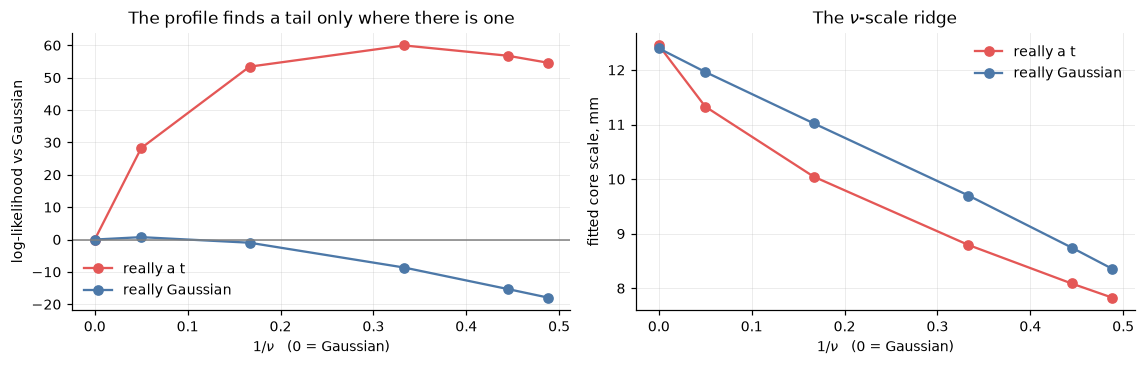

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
for k, (label, col) in enumerate((('really a t', '#e45756'),
                                  ('really Gaussian', '#4c78a8'))):
    p = pd.DataFrame(out[label]['profile'])
    x = 1.0 / np.array(p.nu)          # 0 is the Gaussian
    ax[0].plot(x, p.vs_gaussian, 'o-', color=col, lw=1.5, label=label)
    ax[1].plot(x, p.sigma_mm, 'o-', color=col, lw=1.5, label=label)
ax[0].axhline(0.0, color='0.5', lw=1)
ax[0].set(xlabel=r'$1/\nu$   (0 = Gaussian)', ylabel='log-likelihood vs Gaussian',
          title='The profile finds a tail only where there is one')
ax[0].legend()
ax[1].set(xlabel=r'$1/\nu$   (0 = Gaussian)', ylabel='fitted core scale, mm',
          title=r'The $\nu$-scale ridge')
ax[1].legend()
fig.tight_layout()

Both directions come out, and the contrast is the point:

* On darts that really are a t, the profile beats the Gaussian by **+57
  log-likelihood units** at no cost in parameters. There is a tail, and it is not
  a close call.
* On darts that really are Gaussian, the best it can manage is **+0.75** at
  $\nu = 20$. It nominates a large finite $\nu$ because the profile is flat up
  there, but it cannot find a tail worth having. Two orders of magnitude separate
  the two answers.

And a caveat that matters for anyone planning to use this on a real player. The
profile locates the *peak* at $\nu = 3$ when the truth is 2.25, and everything
from 2.05 to 3 sits within five log-units. From 750 darts of nothing but scores,
**$\nu$ is barely identified** -- the data says confidently that there is a tail
and only loosely how heavy it is. Notebook 21 pinned $\nu$ far more sharply, but
it had thousands of darts per player and it knew which *bed* each one hit, not
just what it scored.

The right-hand panel shows why that is not a defect to be engineered away. The
fitted core climbs steadily with the $\nu$ it was fitted at -- 7.8mm at
$\nu = 2.05$, 12.4mm at the Gaussian -- so $\nu$ and the scale are trading off
along a ridge, and a point estimate of either without the other is not worth
much. The profile is the honest object.

## 4 · The design side is the same weight again

`design.py` differentiates the throw kernel to get the Fisher information of a
session. For a Gaussian, $\log W = -q/2$ and the score function is
$\partial(-q/2)/\partial\theta$. For a t, $\log W = -\tfrac{\nu+2}{2}\log(1 +
q/\nu)$ and

$$\frac{\partial \log W}{\partial \theta}
   = \frac{\nu+2}{\nu+q} \cdot \frac{\partial(-q/2)}{\partial\theta}$$

-- the Gaussian score function times **the same $u$**, for the same reason. That
is why the design results have to be recomputed rather than adjusted: the
quantity has changed shape, not size.

Which leaves the question of whether the recomputation is right. The check that
settles it is a cross-implementation one: `ScoreLikelihood` evaluates the t
density directly on the pixel grid, `design.py` correlates score masks with an
analytically differentiated kernel, and the two share no code beyond the board.

In [8]:
allowed = np.unique(BOARD).astype(int)
S = np.array([[16.0 ** 2, 40.0], [40.0, 13.0 ** 2]])
target = (FIT_PX // 2 - 20, FIT_PX // 2 + 12)
from darts.transitions import _correlate_fft

def p_direct(bias, Smat, nu):
    mu = np.array([(target[1] - FIT_PX // 2) * MM + bias[0],
                   (target[0] - FIT_PX // 2) * MM + bias[1]])
    pr = ScoreLikelihood(board=BOARD, nu=nu).score_probabilities(mu, Smat)
    return np.array([pr[int(s)] for s in allowed])

masks = np.stack([(BOARD == s).astype(float) for s in allowed])
zero = int(np.flatnonzero(allowed == 0)[0])
print('analytic derivative vs finite differences of an independent density:')
for nu in (None, NU):
    numeric, h = [], 1e-4
    for k in range(2):
        e = np.zeros(2); e[k] = h
        numeric.append((p_direct(e, S, nu) - p_direct(-e, S, nu)) / (2 * h))
    for i, j in [(0, 0), (0, 1), (1, 1)]:
        E = np.zeros((2, 2)); E[i, j] = E[j, i] = 1.0
        hh = 1e-4 * S[0, 0]
        numeric.append((p_direct(np.zeros(2), S + hh * E, nu)
                        - p_direct(np.zeros(2), S - hh * E, nu)) / (2 * hh))
    _, dK = kernel_derivatives(FIT_PX, S, MM, nu=nu)
    analytic = np.stack([_correlate_fft(masks, d, pad=nu is not None)[
        :, target[0], target[1]] for d in dK])
    if nu is not None:
        analytic[:, zero] = -(np.delete(analytic, zero, axis=1)).sum(axis=1)
    err = np.abs(analytic - np.stack(numeric)).max()
    print(f'   {"gaussian" if nu is None else f"t, nu={nu:g}":>12}: '
          f'max difference over all five parameters and every score {err:.2e}')

analytic derivative vs finite differences of an independent density:


       gaussian: max difference over all five parameters and every score 2.42e-12


     t, nu=2.25: max difference over all five parameters and every score 1.83e-12


Agreement to **2e-12** for both, over all five parameters and every score on the
board.

That is a stronger statement than it looks. `ScoreLikelihood` evaluates the
density on the pixel grid and books the off-board mass as a miss; `design.py`
correlates score masks with an analytically differentiated kernel, zero-pads the
transform and reconstructs $P(0)$ as one minus everything else. They share no
code beyond the board array. So the $(\nu+2)/(\nu+q)$ factor really is the
derivative of $\log\,(1 + q/\nu)^{-(\nu+2)/2}$, and the two modules agree about
what a Student-t throw is.

## 5 · Does the predicted standard error mean anything?

The design machinery predicts $\mathrm{SE}(\hat\sigma) = \sqrt{c^\top M^{-1}
c / n}$. That is an asymptotic statement about an estimator, so the way to find
out whether it is usable is to run the estimator many times and look at the
spread of what comes back.

In [9]:
SE_DESIGN = [np.array([0.0, 103.0]), np.array([-103.0, 0.0])]


def se_check(nu, scale=12.0, n_per=200, n_rep=25, design=SE_DESIGN):
    maps = information_maps(FIT_PX, scale, board=BOARD, nu=nu)
    pts = np.stack([[int(round(t[1] / MM)) + FIT_PX // 2,
                     int(round(t[0] / MM)) + FIT_PX // 2] for t in design])
    M = design_information(information_at_points(maps, pts), np.ones(len(pts)))
    pred = sigma_standard_error(M, n_per * len(design), scale ** 2 * np.eye(2))
    fits = np.array([
        fit_multi_target(simulate_session(design, n_per, [0.0, 0.0],
                                          scale ** 2 * np.eye(2), board=BOARD,
                                          seed=1000 + r, nu=nu),
                         board=BOARD, tol=1e-10, max_iter=1500, nu=nu)['sigma_mm']
        for r in range(n_rep)])
    emp = fits.std(ddof=1)
    return dict(nu='gaussian' if nu is None else f'nu={nu:g}',
                predicted_se=round(pred, 4), empirical_se=round(float(emp), 4),
                se_of_that=round(float(emp / np.sqrt(2 * (n_rep - 1))), 4),
                ratio=round(float(emp / pred), 3),
                mean_fit=round(float(fits.mean()), 3))

print(f'{25} sessions of 400 darts at a 12mm player, fitted each time:')
print(pd.DataFrame([se_check(None), se_check(NU)]).to_string(index=False))

25 sessions of 400 darts at a 12mm player, fitted each time:


      nu  predicted_se  empirical_se  se_of_that  ratio  mean_fit
gaussian        0.5172        0.4453      0.0643  0.861    12.017
 nu=2.25        0.6443        0.5066      0.0731  0.786    12.055


The prediction is in the right place for both, and conservative for both: the
actual spread of fits comes in about 14% below the predicted standard error for
the Gaussian and 21% below for the t, against a sampling uncertainty on those
spreads of about 14% each. The estimator is unbiased in both cases -- 12.02 and
12.06 against a truth of 12.

So the asymptotic formula is usable for planning a session under a t, in the same
way and to the same degree it already was under a Gaussian. It is not exact at
400 darts; it errs toward asking for slightly more darts than are needed, which
is the direction one would choose to err in.

## 6 · The answers that move

Two published numbers are at stake. **Where to throw** (notebook 09: the bull
below about 13mm, the big single at ~136mm above it) and **for how long**
(notebook 10: an elite player proves a millimetre in 233 darts, a pub player in
4,857).

The dart counts need care to compare. A millimetre of Gaussian $\sigma$ is not a
millimetre of Student-t core -- they are different parameters of different
models -- so the improvement to detect has to be converted the same way notebook
22 converted the player: through what the two have in common, the three-dart
average. `matched_scale` supplies it.

In [10]:
cands = candidate_targets(DESIGN_PX, point_stride=4)
mm512 = mm_per_pixel(DESIGN_PX)
rows = []
for band, sigma in ABILITY_BANDS.items():
    for nu in (None, 5.0, 3.0, 2.25):
        scale = matched_scale(sigma, nu, board=BOARD512)
        maps = information_maps(DESIGN_PX, scale, board=BOARD512, nu=nu)
        c = sigma_gradient(scale ** 2 * np.eye(2))
        i, v, _ = best_single_target(information_at_points(maps, cands), c)
        t = cands[i]
        # 1mm of Gaussian sigma is this much t core, at this band
        delta = (matched_scale(sigma + 0.5, nu, board=BOARD512)
                 - matched_scale(sigma - 0.5, nu, board=BOARD512))
        rows.append(dict(band=band, sigma=sigma, nu=nu, scale=round(scale, 2),
                         best=region_label(t, DESIGN_PX),
                         r_mm=round(float(np.hypot(*(t - DESIGN_PX // 2)) * mm512), 1),
                         S=round(float(np.sqrt(v)), 3),
                         darts=round(darts_to_detect(np.sqrt(v), delta))))
        print('.', end='', flush=True)
design_t = pd.DataFrame(rows)
print()
print('best single target, and darts a session to prove the equivalent of 1mm '
      'of Gaussian sigma:')
print(design_t.to_string(index=False))

.

.

.

.

.

...

.

.

.

.


best single target, and darts a session to prove the equivalent of 1mm of Gaussian sigma:
        band  sigma   nu  scale best  r_mm      S  darts
       elite    6.5  NaN   6.50 BULL   0.0  3.851    233
       elite    6.5 5.00   5.82 BULL   0.0  4.325    372
       elite    6.5 3.00   5.41 BULL   0.0  4.502    449
       elite    6.5 2.25   5.09 BULL   0.0  4.609    506
         pro    8.0  NaN   8.00 BULL   0.0  4.655    340
         pro    8.0 5.00   7.18 BULL   0.0  5.307    515
         pro    8.0 3.00   6.71 BULL   0.0  5.549    610
         pro    8.0 2.25   6.34 BULL   0.0  5.682    680
      county   10.0  NaN  10.00 BULL   0.0  6.105    585
      county   10.0 5.00   9.09 BULL   0.0  6.791    759
      county   10.0 3.00   8.56 BULL   0.0  7.113    861
      county   10.0 2.25   8.15 BULL   0.0  7.306    942
super_league   13.0  NaN  13.00 BULL   0.0  9.050   1286
super_league   13.0 5.00  12.08 BULL   0.0  9.614   1397
super_league   13.0 3.00  11.53 BULL   0.0  9.946   15

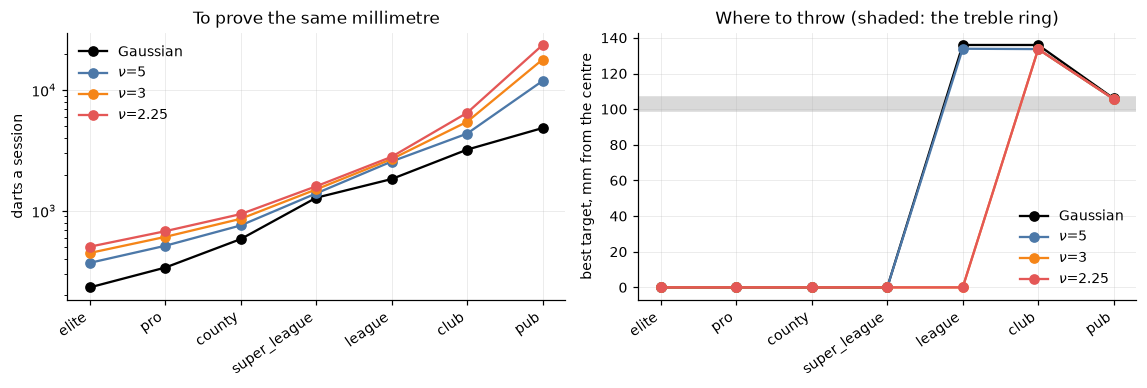

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6))
x = np.arange(len(BANDS))
for nu, col, lab in ((None, 'k', 'Gaussian'), (5.0, '#4c78a8', r'$\nu$=5'),
                     (3.0, '#f58518', r'$\nu$=3'), (2.25, '#e45756', r'$\nu$=2.25')):
    sub = design_t[design_t.nu.isna() if nu is None else design_t.nu == nu]
    sub = sub.set_index('band').loc[BANDS]
    ax[0].semilogy(x, sub.darts, 'o-', color=col, lw=1.5, label=lab)
    ax[1].plot(x, sub.r_mm, 'o-', color=col, lw=1.5, label=lab)
ax[0].set_xticks(x, BANDS, rotation=35, ha='right')
ax[0].set(ylabel='darts a session', title='To prove the same millimetre')
ax[0].legend()
ax[1].axhspan(99, 107, color='0.85', zorder=0)
ax[1].set_xticks(x, BANDS, rotation=35, ha='right')
ax[1].set(ylabel='best target, mm from the centre',
          title='Where to throw (shaded: the treble ring)')
ax[1].legend()
fig.tight_layout()

**Where to throw survives; the threshold moves.**

Under a Gaussian the published rule is the bull up to about 13mm and the big
single at ~136mm above it. Under a t the bull holds on **longer**: at the league
band, $\sigma = 16$mm, the Gaussian has already moved out to the big single and
the t at $\nu = 3$ or 2.25 is still at the bull. Only at the club band and beyond
do they agree again on a big single at ~134mm, and for the widest players both
say a treble at ~106mm -- the T5 or the T11, which are the same recommendation in
two symmetric places.

The structure of notebook 09's answer -- bull for tight players, big single for
loose ones, treble ring for the very loose -- is intact. The number attached to
it is not.

**How long it takes does not survive.** Reading the last column against its
Gaussian row:

| band | Gaussian | t, $\nu$=2.25 | ratio |
|---|---|---|---|
| elite | 233 | 506 | 2.2× |
| pro | 340 | 680 | 2.0× |
| county | 585 | 942 | 1.6× |
| super league | 1,286 | 1,600 | 1.2× |
| league | 1,837 | 2,807 | 1.5× |
| club | 3,218 | 6,490 | 2.0× |
| pub | 4,857 | **23,634** | 4.9× |

The Gaussian column reproduces notebook 10 exactly -- 233 darts for an elite
player and 4,857 for a pub player -- which is worth stating, because it came out
of a rebuilt kernel, a rebuilt normalisation and a padded transform.

So the roadmap's question has an answer, and it is the same answer in every band:
a heavy tail carries **less** information about the core, not more. It could have
gone the other way. It did not, and the reason is the weight in section 1 -- the
darts a Gaussian reads as the loudest evidence about width are exactly the ones a
t discounts.

Two caveats on the size of the effect. The improvement being detected has been
converted through `matched_scale`, because a millimetre of Gaussian $\sigma$ is
not a millimetre of t core; that conversion is what makes the pub row so
dramatic, since a millimetre of Gaussian $\sigma$ there is only 0.63mm of core.
And this whole table is conditional on knowing $\nu$, which section 3 showed a
few hundred darts do not tell you. A session that has to learn $\nu$ as well will
be longer still.

## Conclusion

**Fitting a t costs one weight.** A Student-t is a Gaussian whose width is
redrawn every dart, so the dart's width is a second latent variable that slots
into the sum the landing point already needed. The E step gains
$u = (\nu+2)/(\nu+q)$; the M step is the same weighted Gaussian one. At
$\nu = \infty$ the whole thing reproduces the old fit exactly, and `nu=None` runs
the code it always did.

**It recovers what a Gaussian cannot.** From 750 darts of a t with an 8.0mm core,
the t fit returns 8.09mm and the Gaussian returns 12.45mm -- the same
core-versus-tail compromise notebook 21 measured on real players. It does not fix
the bias, which was being estimated badly for an unrelated reason.

**$\nu$ is profiled, not estimated, and from scores it is only loosely pinned.**
The profile separates a real tail (+57 log-units) from no tail (+0.75) by two
orders of magnitude, but locates $\nu$ itself only to within the low end of the
grid, and the fitted core slides along a ridge with it. Anyone quoting a $\nu$
from a scoresheet should quote the profile.

**The design side is the same weight again**, and that is not a coincidence: the
t's score function is the Gaussian's multiplied by $u$. Two modules that share no
code agree on the derivative to 2e-12, and the predicted standard error tracks
the spread of actual fits about as well as it did for a Gaussian.

**The published measurement answers split.** Where to throw is robust in
structure -- bull, then big single, then treble ring -- but the bull holds
optimal further into the wide bands than the Gaussian said. How long to throw is
not robust at all: **233 darts to prove a millimetre becomes 506**, and a pub
player's 4,857 becomes 23,634. The roadmap asked which way heavy tails would
move the information and noted it was not obvious. It is less, everywhere, by a
factor of between 1.2 and 4.9.

**What is still Gaussian.** `darts/bayes.py` and `darts/throw_shape.py` are
untouched, so the live belief updates and the anisotropy work still assume a
Gaussian throw. And every number here is conditional on a $\nu$ the fitting side
cannot yet pin down from a scoresheet -- which makes measuring one real player
with coordinates, the thing the roadmap has wanted all along, worth more now than
it was before.